In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [17]:
ia_data = pd.read_csv('/content/artificial1d.csv').copy()
ia_data.head()
ia_data.columns = ['x', 'y']
ia_data.head()


x = ia_data['x'].values
y = ia_data['y'].values

X = np.vstack([np.ones_like(x), x]).T

w_chapeu = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ w_chapeu
mse = np.mean((y - y_pred) ** 2)

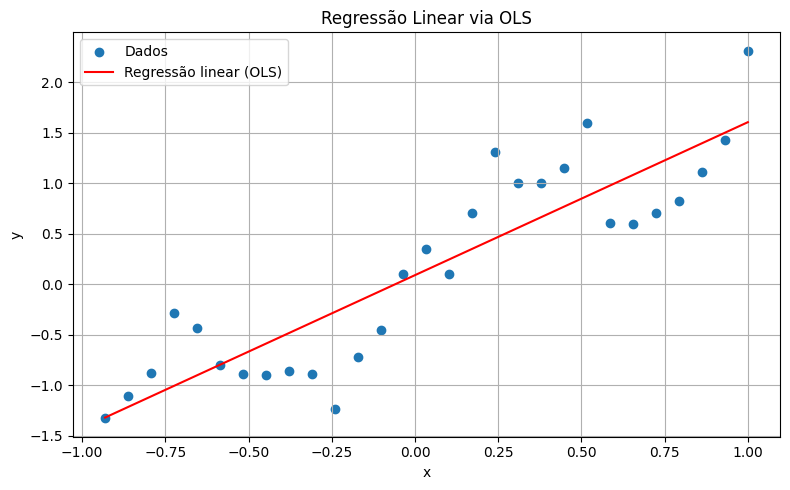

(array([0.08956111, 1.51328267]), np.float64(0.20771235894617687))

In [18]:
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='Dados')
plt.plot(x, y_pred, color='red', label='Regressão linear (OLS)')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Regressão Linear via OLS')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

w_chapeu, mse

In [20]:
da = pd.read_csv('//content/artificial1d.csv', header=None).copy()
da.columns = ['x', 'y']
da.head()

,x,y
0,-1.000000,-2.082017
1,-0.931034,-1.326980
2,-0.862069,-1.105598
3,-0.793103,-0.873946
4,-0.724138,-0.285027


Parâmetros finais: w1 = 0.09, w2 = 1.46
MSE final: 0.2087


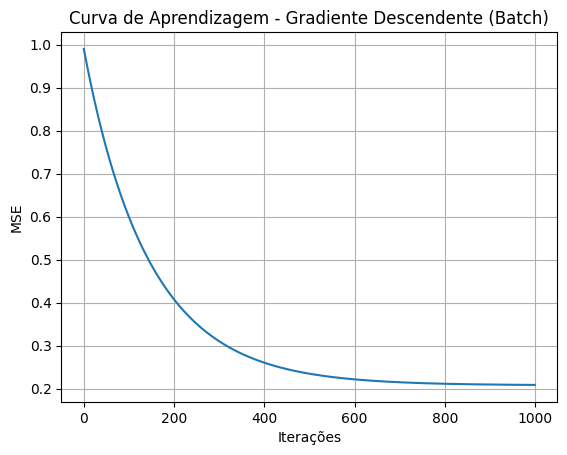

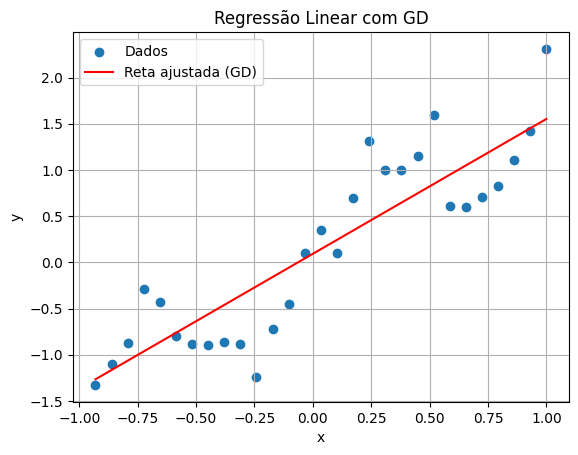

In [37]:

# Carregar os dados
da = pd.read_csv('/content/artificial1d.csv').copy()
da.columns = ['x', 'y']
x = da['x'].values
y = da['y'].values
n = len(x)

# Hiperparâmetros
alfa = 0.01
it = 1000

# Inicializar os parâmetros
w1 = 0
w2 = 0

# Lista para armazenar o MSE a cada iteração
mse_list = []

# Algoritmo GD (batch)
for i in range(it):
    y_chapeu = w1 + w2 * x
    error = y - y_chapeu

    mse = (1/n) * np.sum(error ** 2)
    mse_list.append(mse)

    w1 += alfa * (1/n) * np.sum(error)
    w2 += alfa * (1/n) * np.sum(error * x)

# Resultados
print(f"Parâmetros finais: w1 = {w1:.2f}, w2 = {w2:.2f}")
print(f"MSE final: {mse_list[-1]:.4f}")

# Plotar curva de aprendizagem
plt.plot(range(it), mse_list)
plt.xlabel("Iterações")
plt.ylabel("MSE")
plt.title("Curva de Aprendizagem - Gradiente Descendente (Batch)")
plt.grid(True)
plt.show()

# Plotar reta ajustada
plt.scatter(x, y, label="Dados")
plt.plot(x, y_chapeu, color='red', label="Reta ajustada (GD)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Regressão Linear com GD")
plt.legend()
plt.grid(True)
plt.show()


In [34]:
# Carregar os dados
ia_datac = pd.read_csv('/content/artificial1d.csv').copy()
ia_datac.columns = ['x', 'y']
N = ia_datac.shape[0]

# Hiperparâmetro de taxa de aprendizado
alfa = 0.1

# Inicialização dos parâmetros
w1 = 7
w2 = 27

# Número total de iterações
max_iter = 10000
it = 0
mse_history = []

# Algoritmo SGD
while it <= max_iter:
    # Embaralhar os dados a cada iteração
    amostra = ia_datac.sample(frac=1).to_numpy()

    for i in amostra:
        x_i = i[0]
        y_i = i[1]

        y_hat = w1 + w2 * x_i
        erro = y_i - y_hat

        w1 += alfa * (1 / N) * erro
        w2 += alfa * (1 / N) * erro * x_i

        if it % 100 == 0:
            y_pred_temp = w1 + w2 * ia_datac['x']
            erro_temp = ia_datac['y'] - y_pred_temp
            mse = (1 / (2 * N)) * np.sum(erro_temp ** 2)
            mse_history.append(mse)
        it += 1
        if it > max_iter:
            break

# Cálculo do MSE final
y_pred = w1 + w2 * ia_datac['x']
erro_final = ia_datac['y'] - y_pred
MSE = (1 / (2 * N)) * np.sum(erro_final ** 2)

# Exibir os resultados
print(f"O valor final dos parâmetros é: w1 = {w1:.2f} e w2 = {w2:.2f}")
print(f"O valor final do MSE é: {MSE:.2f}")

O valor final dos parâmetros é: w1 = 0.09 e w2 = 1.52
O valor final do MSE é: 0.10


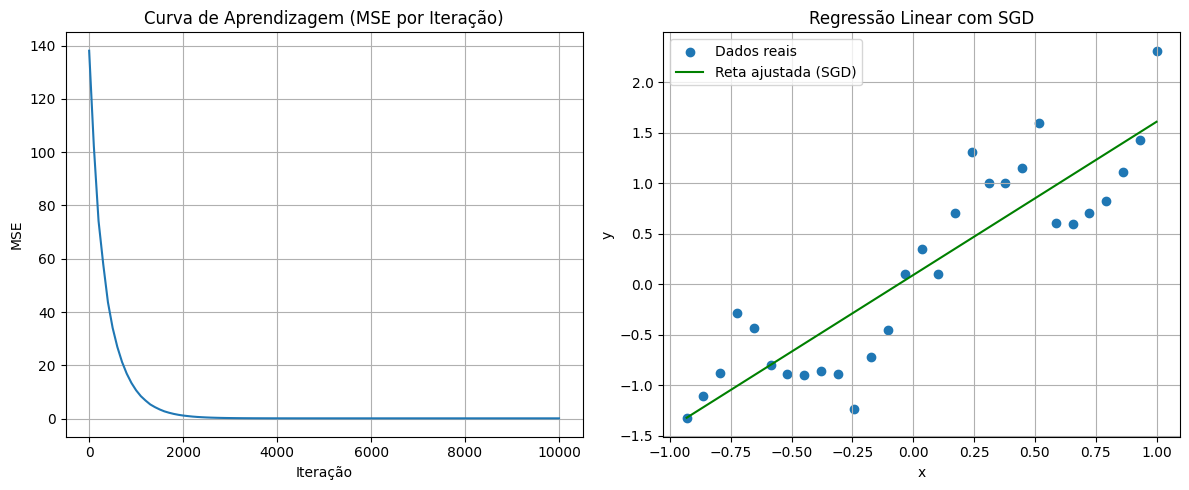

In [35]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(np.arange(0, max_iter + 1, 100), mse_history)
plt.title("Curva de Aprendizagem (MSE por Iteração)")
plt.xlabel("Iteração")
plt.ylabel("MSE")
plt.grid(True)

# Plotar reta final
plt.subplot(1, 2, 2)
plt.scatter(ia_datac['x'], ia_datac['y'], label="Dados reais")
plt.plot(ia_datac['x'], y_pred, color='green', label="Reta ajustada (SGD)")
plt.title("Regressão Linear com SGD")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [44]:
# Carregar o arquivo california.csv
cali = pd.read_csv('/content/california.csv')

# Exibir as primeiras linhas do dataset
cali.head()


,4.168499999999999872e+00,2.000000000000000000e+01,6.700636942675159524e+00,1.178343949044585948e+00,7.450000000000000000e+02,2.372611464968152895e+00,3.879999999999999716e+01,-1.211500000000000057e+02,2.174999999999999822e+00
0,2.8194,24.0,4.762500,1.020833,608.0,2.533333,36.75,-119.85,0.811
1,2.4250,46.0,4.927711,1.018072,772.0,2.325301,36.33,-119.31,0.849
2,3.1205,16.0,3.728477,1.101545,1260.0,2.781457,33.87,-117.99,1.740
3,4.3889,41.0,5.741007,1.199041,837.0,2.007194,34.15,-118.40,3.804
4,2.9934,52.0,3.441379,1.020690,318.0,2.193103,37.57,-122.32,2.563
